In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('mymoviedb.csv',lineterminator='\n')

In [3]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 4.5 MB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [6]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])
print(df["Release_Date"].dtype)

datetime64[us]


In [7]:
df["Release_Date"]=df["Release_Date"].dt.year
print(df["Release_Date"].dtype)

int32


In [8]:
def categorized_col(df,col,labels):
    edges=[df[col].describe()["min"],
           df[col].describe()["25%"],
           df[col].describe()["50%"],
           df[col].describe()["75%"],
           df[col].describe()["max"]]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates="drop")
    return df

In [9]:
labels=["not_popular","below_average","average","popular"]
categorized_col(df,"Vote_Average",labels)
df["Vote_Average"].unique()


['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_average' < 'average' < 'popular']

In [17]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
3,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...
4,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [11]:
df["Vote_Average"].value_counts()

Vote_Average
not_popular      2467
popular          2450
average          2412
below_average    2398
Name: count, dtype: int64

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,below_average,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,popular,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,average,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
# split the strings into lists
df['Genre'] = df['Genre'].str.split(', ')
# explode the lists
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
3,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...
4,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [15]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Action,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Adventure,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
2,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
3,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Crime,https://image.tmdb.org/t/p/original/74xTEgt7R3...
4,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,popular,en,Mystery,https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [18]:
 #casting column into category
df['Genre'] = df['Genre'].astype('category')
# confirming changes
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Release_Date       25793 non-null  int32   
 1   Title              25793 non-null  str     
 2   Overview           25793 non-null  str     
 3   Popularity         25793 non-null  float64 
 4   Vote_Count         25793 non-null  int64   
 5   Vote_Average       25552 non-null  category
 6   Original_Language  25793 non-null  str     
 7   Genre              25793 non-null  category
 8   Poster_Url         25793 non-null  str     
dtypes: category(2), float64(1), int32(1), int64(1), str(4)
memory usage: 10.6 MB


In [20]:
df.nunique()

Release_Date          102
Title                9513
Overview             9822
Popularity           8160
Vote_Count           3266
Vote_Average            4
Original_Language      43
Genre                  19
Poster_Url           9827
dtype: int64

In [21]:
# setting up seaborn configurations
sns.set_style('whitegrid') 

In [23]:
# showing stats. on genre column
df['Genre'].describe()

count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

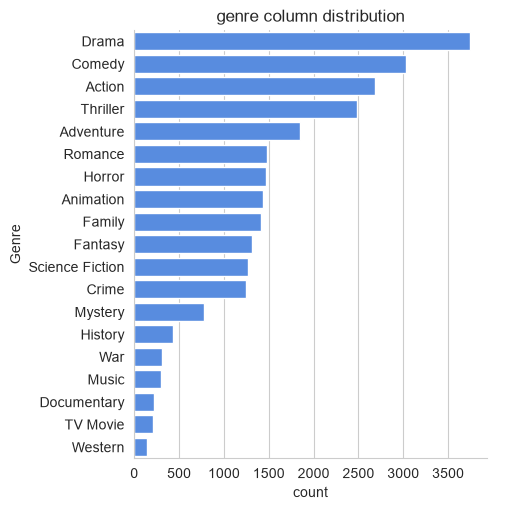

In [30]:
# visualizing genre column
sns.catplot(y = 'Genre', data = df, kind = 'count', 
order = df['Genre'].value_counts().index,
color = '#4287f5')
plt.title("genre column distribution")
plt.show()

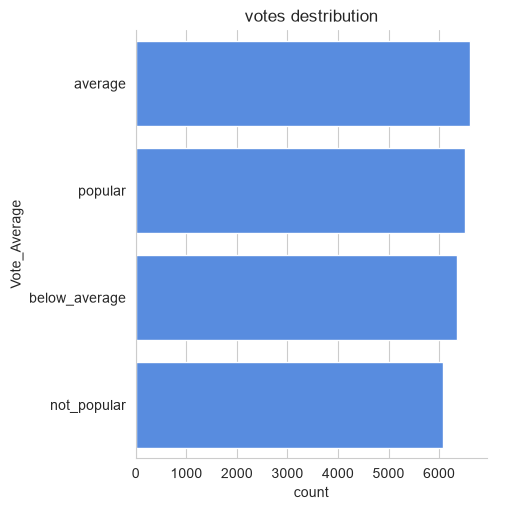

In [31]:
# visualizing vote_average column
sns.catplot(y = 'Vote_Average', data = df, kind = 'count', 
order = df['Vote_Average'].value_counts().index,
color = '#4287f5')
plt.title('votes destribution')
plt.show()

In [32]:
# checking max popularity in dataset
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
25787,2021,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,Music,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25788,2021,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,Drama,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25789,2021,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,average,en,History,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
25790,1984,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,War,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...
25791,1984,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,Drama,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...
25792,1984,Threads,Documentary style account of a nuclear holocau...,13.354,186,popular,en,Science Fiction,https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


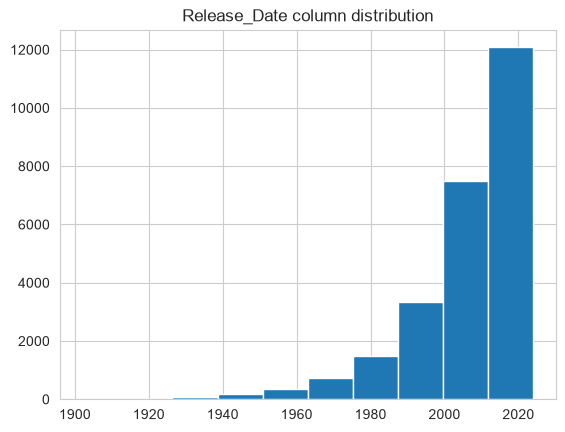

In [34]:
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()

# Netflix Movies Data Project - Summary of Findings

### Q1: What is the most frequent genre in the dataset?
* **Answer:** **Drama** is the most frequent genre, appearing in **more than 14%** of the entries among 20 distinct genres.

### Q2: Which genre has the highest votes?
* **Answer:** **25.5%** of the dataset is classified under popular votes (6,520 rows). **Drama** holds the highest popularity among fans, accounting for **more than 18.5%** of movie popularities.

### Q3: What movie got the highest popularity, and what are its genres?
* **Answer:** ***Spider-Man: No Way Home*** achieved the highest popularity rate.
* **Genres:** Action, Adventure, and Science Fiction.

### Q4: What movie got the lowest popularity, and what are its genres?
* **Answer:** ***Threads* ('The United States, Thread')** recorded the lowest popularity rate.
* **Genres:** Music, Drama, War, Sci-Fi, and History.

### Q5: Which year has the most filmed movies?
* **Answer:** The year **2020** recorded the highest filming rate/movie output in the dataset.

## Key Insights

1. **Volume and Fan Engagement Dominance:**
   * **Drama** dominates both dataset presence (>14% share) and audience vote share (>18.5% of top-voted entries).

2. **Mainstream Blockbuster Appeal:**
   * High-budget **Action, Adventure, and Sci-Fi** combinations drive peak individual movie popularity, proving that high-concept commercial films capture maximum audience attention.

3. **Multi-Genre Complexity Risk:**
   * Combining too many heavy genres (e.g., War + History + Music + Sci-Fi + Drama) limits broader commercial reach, resulting in lower overall popularity scores.

## Conclusion

Based on the data analysis, **Drama** emerges as the most dominant genre in this dataset. It leads not only in overall frequency (present in more than 14% of all titles across 20 genres) but also in viewer engagement, capturing over 18.5% of the total popular votes.

When evaluating individual movie performances, mainstream blockbusters blending **Action, Adventure, and Science Fiction**—such as *Spider-Man: No Way Home*—achieve the highest popularity scores. Conversely, complex, multi-genre niche titles like *Threads* (incorporating Music, Drama, War, Sci-Fi, and History) sit at the lowest end of the popularity scale.
